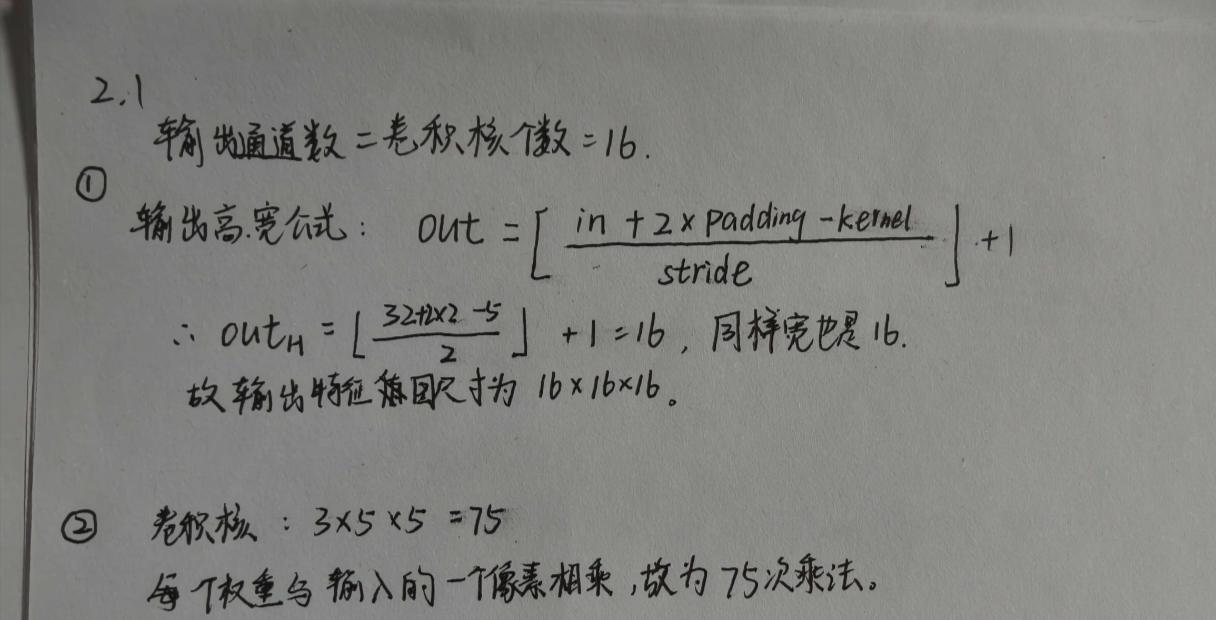

In [5]:
#2.2 手动实现最大池化层
import numpy as np

def max_pool2d(input, kernel_size, stride=None, padding=0):
    """
    input: (H, W) 或 (C, H, W) 或 (N, C, H, W)
    kernel_size: int or (kh, kw)
    stride: int or (sh, sw), default=kernel_size
    padding: int or (ph, pw)
    """
    if isinstance(kernel_size, int):
        kh = kw = kernel_size
    else:
        kh, kw = kernel_size
    
    if stride is None:
        sh = sw = kh
    elif isinstance(stride, int):
        sh = sw = stride
    else:
        sh, sw = stride
    
    if isinstance(padding, int):
        ph = pw = padding
    else:
        ph, pw = padding
    
    original_shape = input.shape
    input = np.array(input)
    
    if input.ndim == 2:
        input = input[None, None, :, :]
    elif input.ndim == 3:
        input = input[None, :, :, :]
    
    N, C, H, W = input.shape
    H_out = (H + 2*ph - kh) // sh + 1
    W_out = (W + 2*pw - kw) // sw + 1
    
    input_pad = np.pad(input, ((0,0), (0,0), (ph, ph), (pw, pw)), mode='constant')
    
    output = np.zeros((N, C, H_out, W_out))
    
    for n in range(N):
        for c in range(C):
            for i in range(H_out):
                for j in range(W_out):
                    h_start = i * sh
                    h_end = h_start + kh
                    w_start = j * sw
                    w_end = w_start + kw
                    window = input_pad[n, c, h_start:h_end, w_start:w_end]
                    output[n, c, i, j] = np.max(window)
    
    if len(original_shape) == 2:
        return output[0, 0]
    elif len(original_shape) == 3:
        return output[0]
    return output

# ========== 测试并打印输出 ==========
print("=" * 50)
print("2.2 手动实现最大池化")
print("=" * 50)

# 测试1：2D输入
x2d = np.array([[1, 2, 3, 4],
                [5, 6, 7, 8],
                [9, 10, 11, 12],
                [13, 14, 15, 16]])
print("输入 (4x4):")
print(x2d)
out2d = max_pool2d(x2d, kernel_size=2, stride=2)
print("\n输出 (2x2):")
print(out2d)

# 测试2：4D输入 (batch=1, channel=3, 32x32)
print("\n" + "-" * 30)
x4d = np.random.randn(1, 3, 32, 32)
out4d = max_pool2d(x4d, kernel_size=2, stride=2)
print(f"输入形状: {x4d.shape}")
print(f"输出形状: {out4d.shape}")

2.2 手动实现最大池化
输入 (4x4):
[[ 1  2  3  4]
 [ 5  6  7  8]
 [ 9 10 11 12]
 [13 14 15 16]]

输出 (2x2):
[[ 6.  8.]
 [14. 16.]]

------------------------------
输入形状: (1, 3, 32, 32)
输出形状: (1, 3, 16, 16)


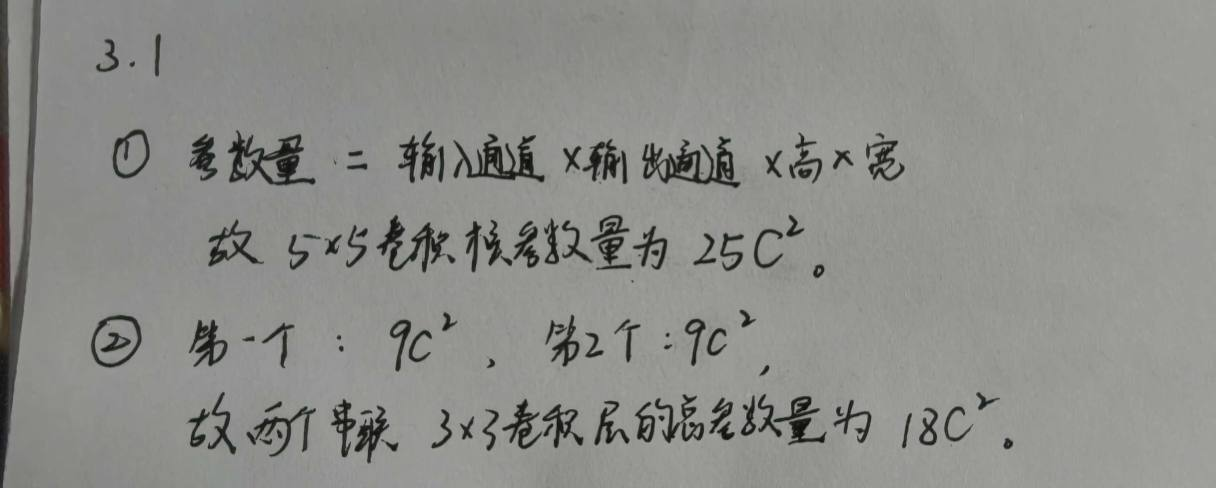

In [4]:
#3.2 NiN 块
import torch
import torch.nn as nn

class NiNBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, stride, padding):
        super(NiNBlock, self).__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size, stride, padding),
            nn.ReLU(),
            nn.Conv2d(out_channels, out_channels, kernel_size=1),
            nn.ReLU(),
            nn.Conv2d(out_channels, out_channels, kernel_size=1),
            nn.ReLU()
        )
    
    def forward(self, x):
        return self.block(x)

# ========== 测试并打印输出 ==========
print("\n" + "=" * 50)
print("3.2 NiN 块")
print("=" * 50)

block = NiNBlock(3, 16, kernel_size=3, stride=1, padding=1)
x = torch.randn(1, 3, 32, 32)
out = block(x)
print(f"输入形状: {x.shape}")
print(f"输出形状: {out.shape}")
print("NiN块结构:")
print(block)


3.2 NiN 块
输入形状: torch.Size([1, 3, 32, 32])
输出形状: torch.Size([1, 16, 32, 32])
NiN块结构:
NiNBlock(
  (block): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(16, 16, kernel_size=(1, 1), stride=(1, 1))
    (3): ReLU()
    (4): Conv2d(16, 16, kernel_size=(1, 1), stride=(1, 1))
    (5): ReLU()
  )
)


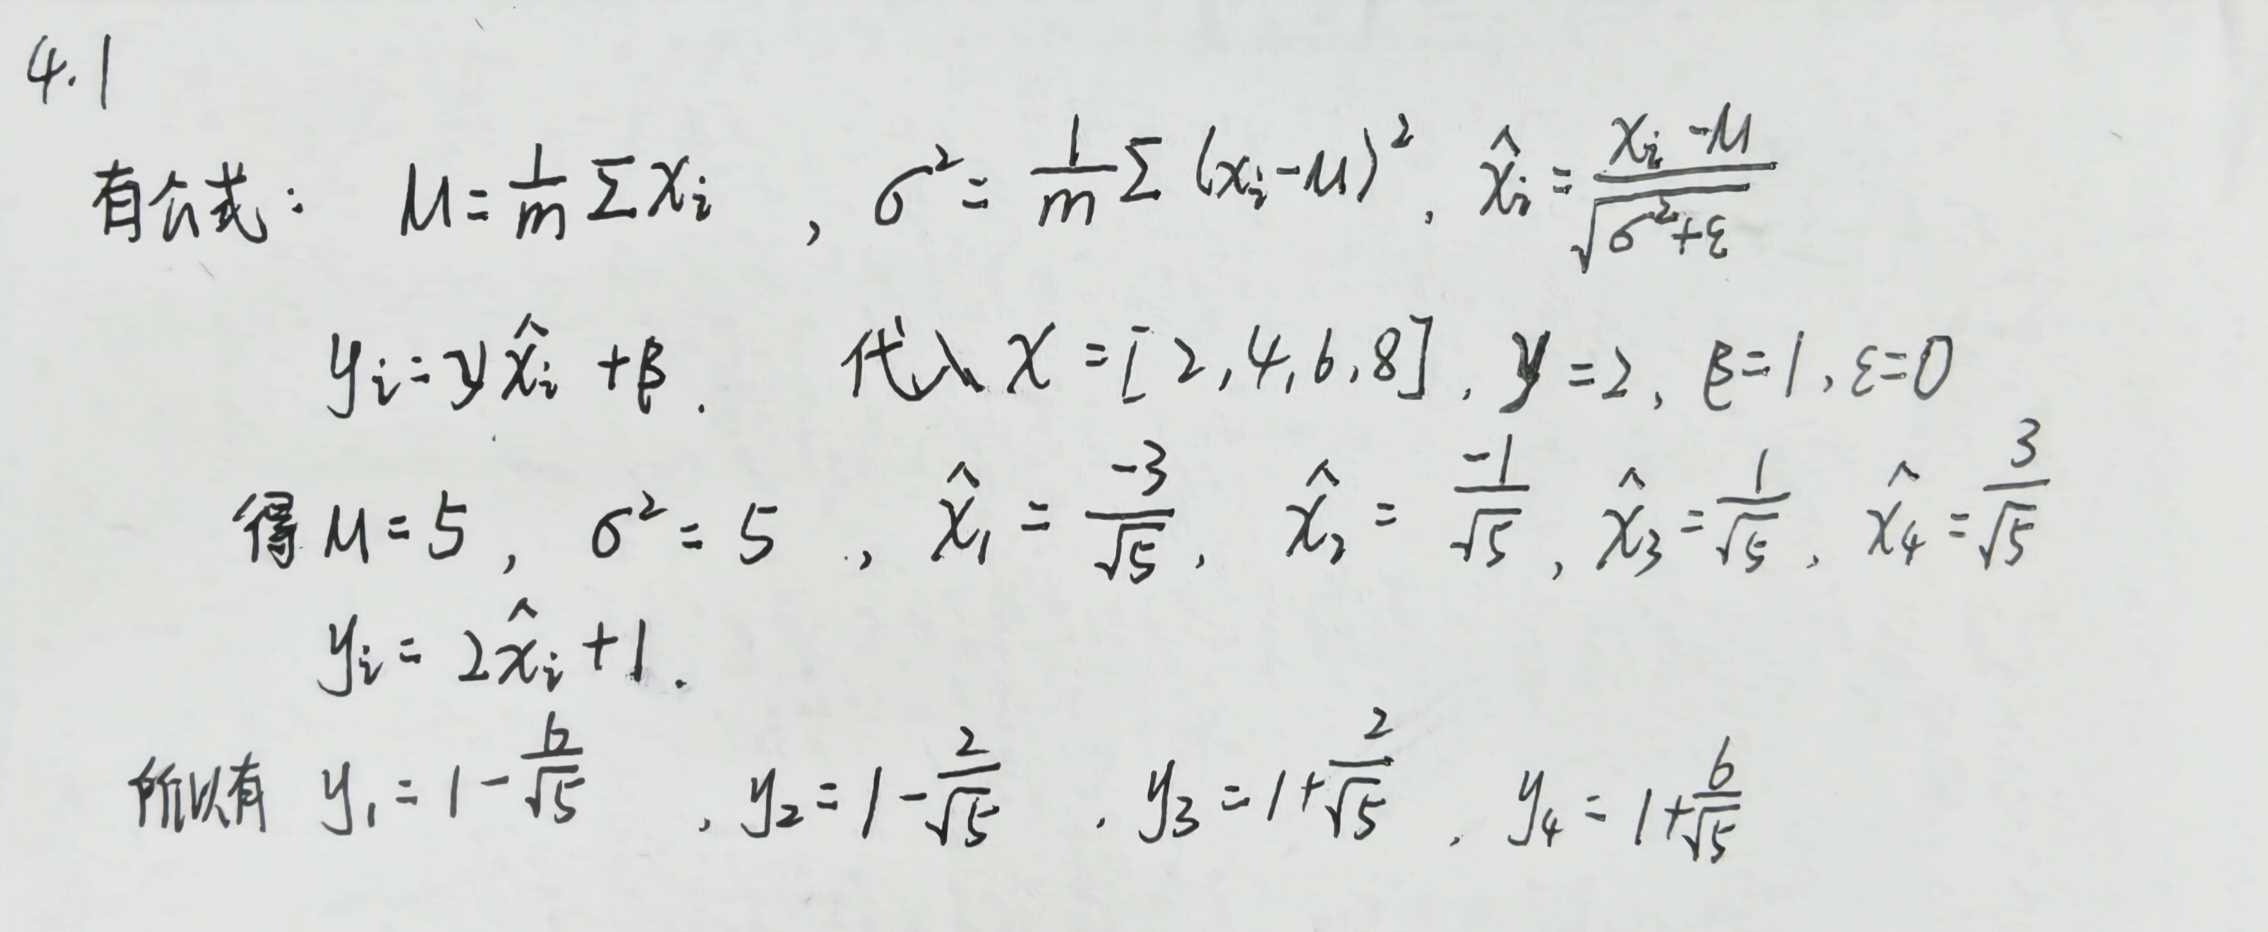

In [6]:
#4.2 残差块
class Residual(nn.Module):
    def __init__(self, in_channels, out_channels, use_1x1conv=False, stride=1):
        super(Residual, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1)
        self.bn2 = nn.BatchNorm2d(out_channels)
        
        self.use_1x1conv = use_1x1conv
        if use_1x1conv:
            self.conv3 = nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride)
        else:
            self.conv3 = None
    
    def forward(self, x):
        y = torch.relu(self.bn1(self.conv1(x)))
        y = self.bn2(self.conv2(y))
        if self.conv3:
            x = self.conv3(x)
        y += x
        return torch.relu(y)

# ========== 测试并打印输出 ==========
print("\n" + "=" * 50)
print("4.2 残差块")
print("=" * 50)

# 情况1：输入输出通道相同，无1x1卷积
res1 = Residual(16, 16, use_1x1conv=False, stride=1)
x1 = torch.randn(1, 16, 32, 32)
out1 = res1(x1)
print(f"情况1 - 输入: {x1.shape} -> 输出: {out1.shape}")
print(f"use_1x1conv=False, stride=1")

# 情况2：通道数改变，使用1x1卷积
res2 = Residual(3, 16, use_1x1conv=True, stride=2)
x2 = torch.randn(1, 3, 32, 32)
out2 = res2(x2)
print(f"\n情况2 - 输入: {x2.shape} -> 输出: {out2.shape}")
print(f"use_1x1conv=True, stride=2")

# 打印残差块结构
print("\n残差块结构 (use_1x1conv=True):")
print(res2)


4.2 残差块
情况1 - 输入: torch.Size([1, 16, 32, 32]) -> 输出: torch.Size([1, 16, 32, 32])
use_1x1conv=False, stride=1

情况2 - 输入: torch.Size([1, 3, 32, 32]) -> 输出: torch.Size([1, 16, 16, 16])
use_1x1conv=True, stride=2

残差块结构 (use_1x1conv=True):
Residual(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
  (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(3, 16, kernel_size=(1, 1), stride=(2, 2))
)


5.1理论计算题
1.底层特征提取层学习通用特征（边缘、纹理），小学习率避免破坏预训练知识；顶层输出层随机初始化，需要大学习率快速适应新任务。
2.目标数据集小且与源数据集相似时,可以采取以下措施防止过拟合：
冻结大部分底层特征层；只微调最后几层或只训练新输出层；使用较小的学习率；使用更强的正则化（如 dropout、权重衰减）。

In [4]:
#5.2 图像增广管道
from torchvision import transforms
from PIL import Image
import torch

# ========== 测试并打印输出 ==========
print("\n" + "=" * 50)
print("5.2 图像增广管道")
print("=" * 50)

augmentation_pipeline = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.08, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.5, contrast=0.5, saturation=0.5),
    transforms.ToTensor()
])

print("增广管道:")
for i, t in enumerate(augmentation_pipeline.transforms):
    print(f"  {i+1}. {t}")

# 创建测试图像
img = Image.new('RGB', (300, 300), color=(255, 0, 0))
print(f"\n原始图像尺寸: {img.size}")

# 应用增广
tensor_img = augmentation_pipeline(img)
print(f"增广后张量形状: {tensor_img.shape}")
print(f"像素值范围: [{tensor_img.min():.3f}, {tensor_img.max():.3f}]")

# 多次运行展示随机性
print("\n多次运行结果 (尺寸验证):")
for i in range(3):
    out = augmentation_pipeline(img)
    print(f"  第{i+1}次: {out.shape}")


5.2 图像增广管道
增广管道:
  1. RandomResizedCrop(size=(224, 224), scale=(0.08, 1.0), ratio=(0.75, 1.3333), interpolation=bilinear, antialias=True)
  2. RandomHorizontalFlip(p=0.5)
  3. ColorJitter(brightness=(0.5, 1.5), contrast=(0.5, 1.5), saturation=(0.5, 1.5), hue=None)
  4. ToTensor()

原始图像尺寸: (300, 300)
增广后张量形状: torch.Size([3, 224, 224])
像素值范围: [0.000, 1.000]

多次运行结果 (尺寸验证):
  第1次: torch.Size([3, 224, 224])
  第2次: torch.Size([3, 224, 224])
  第3次: torch.Size([3, 224, 224])


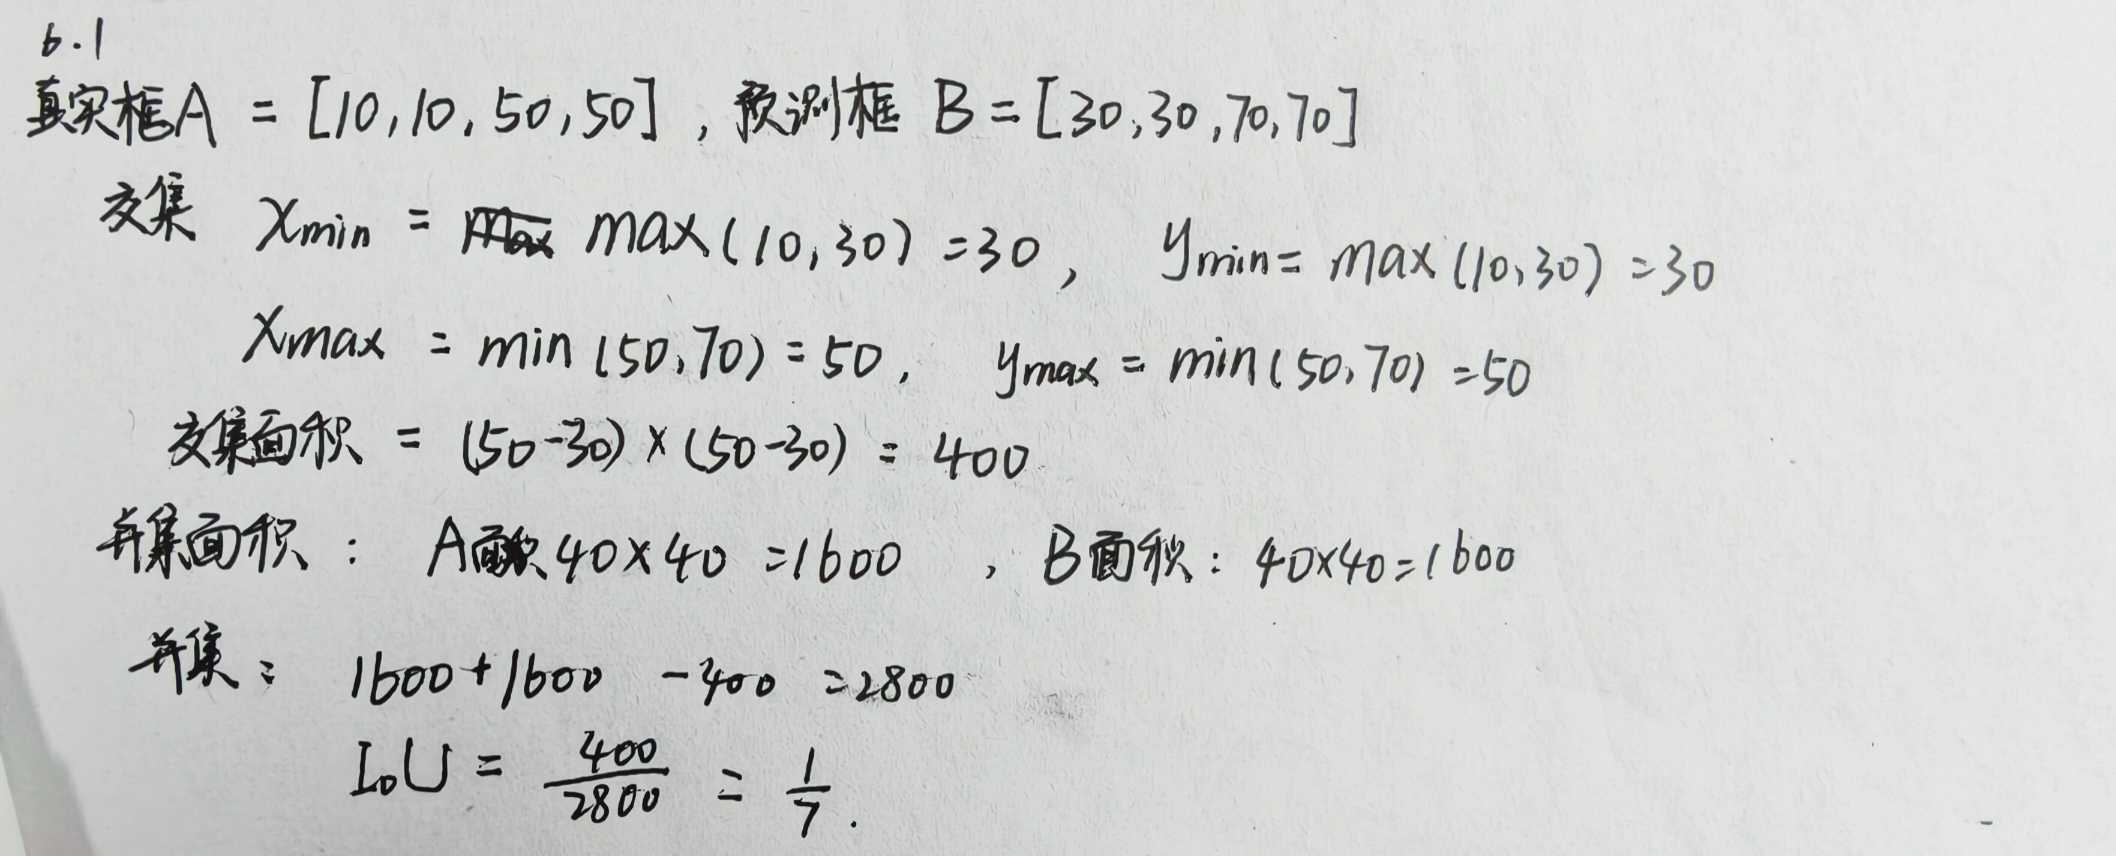

In [8]:
#6.2 标签平滑交叉熵
import torch.nn.functional as F

def label_smoothing_cross_entropy(logits, labels, epsilon=0.1):
    num_classes = logits.shape[-1]
    log_probs = F.log_softmax(logits, dim=-1)
    
    with torch.no_grad():
        true_dist = torch.zeros_like(log_probs)
        true_dist.fill_(epsilon / (num_classes - 1))
        true_dist.scatter_(1, labels.unsqueeze(1), 1 - epsilon)
    
    loss = (-true_dist * log_probs).sum(dim=-1).mean()
    return loss

# ========== 测试并打印输出 ==========
print("\n" + "=" * 50)
print("6.2 标签平滑交叉熵")
print("=" * 50)

torch.manual_seed(42)
logits = torch.randn(4, 10)
labels = torch.tensor([1, 2, 3, 4])

print(f"logits形状: {logits.shape}")
print(f"真实标签: {labels}")

# 标准交叉熵作为对比
ce_loss = F.cross_entropy(logits, labels)
print(f"\n标准交叉熵损失: {ce_loss.item():.6f}")

# 标签平滑
epsilon = 0.1
smoothed_loss = label_smoothing_cross_entropy(logits, labels, epsilon)
print(f"标签平滑损失 (ε={epsilon}): {smoothed_loss.item():.6f}")

# 展示标签平滑分布
num_classes = 10
target_prob = 1 - epsilon
other_prob = epsilon / (num_classes - 1)
print(f"\n标签平滑后的目标分布:")
print(f"  真实类概率: {target_prob:.4f}")
print(f"  其他类概率: {other_prob:.4f}")

# 测试不同 epsilon
print("\n不同 epsilon 下的损失对比:")
for eps in [0.0, 0.05, 0.1, 0.2]:
    loss = label_smoothing_cross_entropy(logits, labels, eps)
    print(f"  ε={eps}: {loss.item():.6f}")


6.2 标签平滑交叉熵
logits形状: torch.Size([4, 10])
真实标签: tensor([1, 2, 3, 4])

标准交叉熵损失: 2.330244
标签平滑损失 (ε=0.1): 2.389562

标签平滑后的目标分布:
  真实类概率: 0.9000
  其他类概率: 0.0111

不同 epsilon 下的损失对比:
  ε=0.0: 2.330244
  ε=0.05: 2.359903
  ε=0.1: 2.389562
  ε=0.2: 2.448880
